# Lab 3 Task 4: Multirate Processing of a Real N310 Capture

Generate the tone file, capture it with the same finite GRC flowgraphs, predict each alias, and compare raw downsampling with filtered resampling.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


<span style="color:#165696"><b>Answer in the report.</b> Include the tone file calculation. For each output, calculate the sample rate, Nyquist interval, expected
alias, and measured spectral peak.</span>

In [2]:
from lab3_dsp import principal_alias
from lab3_tools import analyze_tone_capture, generate_tone_file, plot_task4_analysis

sample_rate_sps = 1_250_000
tone_hz = 100_000
tone_duration_s = 0.25
tone_amplitude = 0.10
transmit_seconds = 20.0
capture_seconds = 8.0

# to do: derive the output rates and predicted aliases.
rate_factor2_sps = sample_rate_sps // 2
rate_ratio7_10_sps = sample_rate_sps * 7 // 10
rate_factor20_sps = sample_rate_sps // 20
alias_factor2_hz = principal_alias(tone_hz, rate_factor2_sps)
alias_ratio7_10_hz = principal_alias(tone_hz, rate_ratio7_10_sps)
alias_factor20_hz = principal_alias(tone_hz, rate_factor20_sps)
tone_file_samples = int(sample_rate_sps * tone_duration_s)
tone_file_bytes = tone_file_samples * 8
capture_samples = int(sample_rate_sps * capture_seconds)
capture_bytes = capture_samples * 8

In [3]:
assert rate_factor2_sps == 625_000
assert rate_ratio7_10_sps == 875_000
assert rate_factor20_sps == 62_500
assert alias_factor2_hz == 100_000
assert alias_ratio7_10_hz == 100_000
assert alias_factor20_hz == -25_000
assert tone_file_samples == 312_500
assert tone_file_bytes == 2_500_000
assert capture_samples == 10_000_000
assert capture_bytes == 80_000_000
print("Rate, alias, and file-size calculations passed.")

Rate, alias, and file-size calculations passed.


In [7]:
report_df = pd.DataFrame({
    "Output": [
        "Factor-2 Decimation",
        "7/10 Resampling",
        "Raw Factor-20 Decimation",
        "Filtered Factor-20 Resampling"
    ],
    "Sample Rate (Hz)": [
        rate_factor2_sps,
        rate_ratio7_10_sps,
        rate_factor20_sps,
        rate_factor20_sps
    ],
    "Nyquist Frequency (Hz)": [
        rate_factor2_sps / 2,
        rate_ratio7_10_sps / 2,
        rate_factor20_sps / 2,
        rate_factor20_sps / 2
    ],"Nyquist Interval (s)": [
        1/(2*rate_factor2_sps),
        1/(2*rate_ratio7_10_sps),
        1/(2*rate_factor20_sps),
        1/(2*rate_factor20_sps)
    ],
    "Expected Alias (Hz)": [
        alias_factor2_hz,
        alias_ratio7_10_hz,
        alias_factor20_hz,
        "Suppressed"
    ],
    "Measured Peak (Hz)": [
        result["peaks_hz"]["Raw factor 2: 625 kS/s"],
        result["peaks_hz"]["Filtered ratio 7/10: 875 kS/s"],
        result["peaks_hz"]["Raw factor 20: 62.5 kS/s"],
        result["peaks_hz"]["Filtered factor 20: 62.5 kS/s"]
    ],
    "Peak Power (dB)": [
        result["powers_db"]["Raw factor 2: 625 kS/s"],
        result["powers_db"]["Filtered ratio 7/10: 875 kS/s"],
        result["powers_db"]["Raw factor 20: 62.5 kS/s"],
        result["powers_db"]["Filtered factor 20: 62.5 kS/s"]
    ]
})

display(report_df)

,Output,Sample Rate (Hz),Nyquist Frequency (Hz),Nyquist Interval (s),Expected Alias (Hz),Measured Peak (Hz),Peak Power (dB)
0,Factor-2 Decimation,625000,312500.0,8.000000e-07,100000.0,100097.656250,-21.859816
1,7/10 Resampling,875000,437500.0,5.714286e-07,100000.0,100082.397461,-21.856656
2,Raw Factor-20 Decimation,62500,31250.0,8.000000e-06,-25000.0,-24902.343750,-21.858690
3,Filtered Factor-20 Resampling,62500,31250.0,8.000000e-06,Suppressed,99.182129,-66.096088


<span style="color:#165696"><b>Answer in the report.</b>  Include the raw-versus-filtered factor-20 comparison. Explain why one path aliases and the other suppresses the tone. Explain why raw factor-20 downsampling produces a strong −25
kHz alias while filtered factor-20 resampling suppresses the original out-of-band tone.</span>

In the raw factor-20 downsampling path, the sample rate is reduced from 1.25 MS/s to 62.5 kS/s without first removing frequencies above the new Nyquist frequency of 31.25 kHz. Because the original 100 kHz tone lies outside this Nyquist range, it aliases into the passband and appears as a strong spectral peak at approximately −25 kHz. In contrast, the filtered factor-20 resampling path applies a low-pass anti-aliasing filter before decimation, removing the out-of-band 100 kHz tone before the sample rate is reduced. As a result, the tone cannot fold back into the spectrum, and the filtered output shows strong suppression of the original tone instead of a prominent alias.

<span style="color:#165696"><b>Answer in the report.</b> Include the GRC settings and exact capture size</span>  
With 312,500 samples, the expected capture size = 312,500 samples * 8 bytes per sample = 2,500,000 bytes.

In [5]:
tone_path = WAVEFORM_DIR / "task4_tone_tx_c64.dat"
tone = generate_tone_file(
    tone_path, sample_rate_sps, tone_hz, tone_duration_s, tone_amplitude
)
print(tone_path, tone_path.stat().st_size, "bytes", "peak", np.max(np.abs(tone)))

/Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3/work/waveforms/task4_tone_tx_c64.dat 2500000 bytes peak 0.10000001


## GNU Radio capture sequence

For our GRC settings, we used the same two GRC files as Task 3. In the transmitter, select `task4_tone_tx_c64.dat`, use a 20.0-second Head, and keep 2.45 GHz and 1.25 MS/s. In the receiver, select `task4_tone_c64.dat` and use an 8.0-second Head. Start the transmitter first, then start the receiver. Confirm 10,000,000 complex64 samples and 80,000,000 bytes.

In [15]:
ls -la work/captures/task4_tone_c64.dat

-rw-rw-r--@ 1 marcpham  staff  80000000 Oct  7 11:35 work/captures/task4_tone_c64.dat


Original 1.25 MS/s                   peak   100.098 kHz, power  -21.860 dB
Raw factor 2: 625 kS/s               peak   100.098 kHz, power  -21.860 dB
Filtered ratio 7/10: 875 kS/s        peak   100.082 kHz, power  -21.857 dB
Raw factor 20: 62.5 kS/s             peak   -24.902 kHz, power  -21.859 dB
Filtered factor 20: 62.5 kS/s        peak     0.099 kHz, power  -66.096 dB


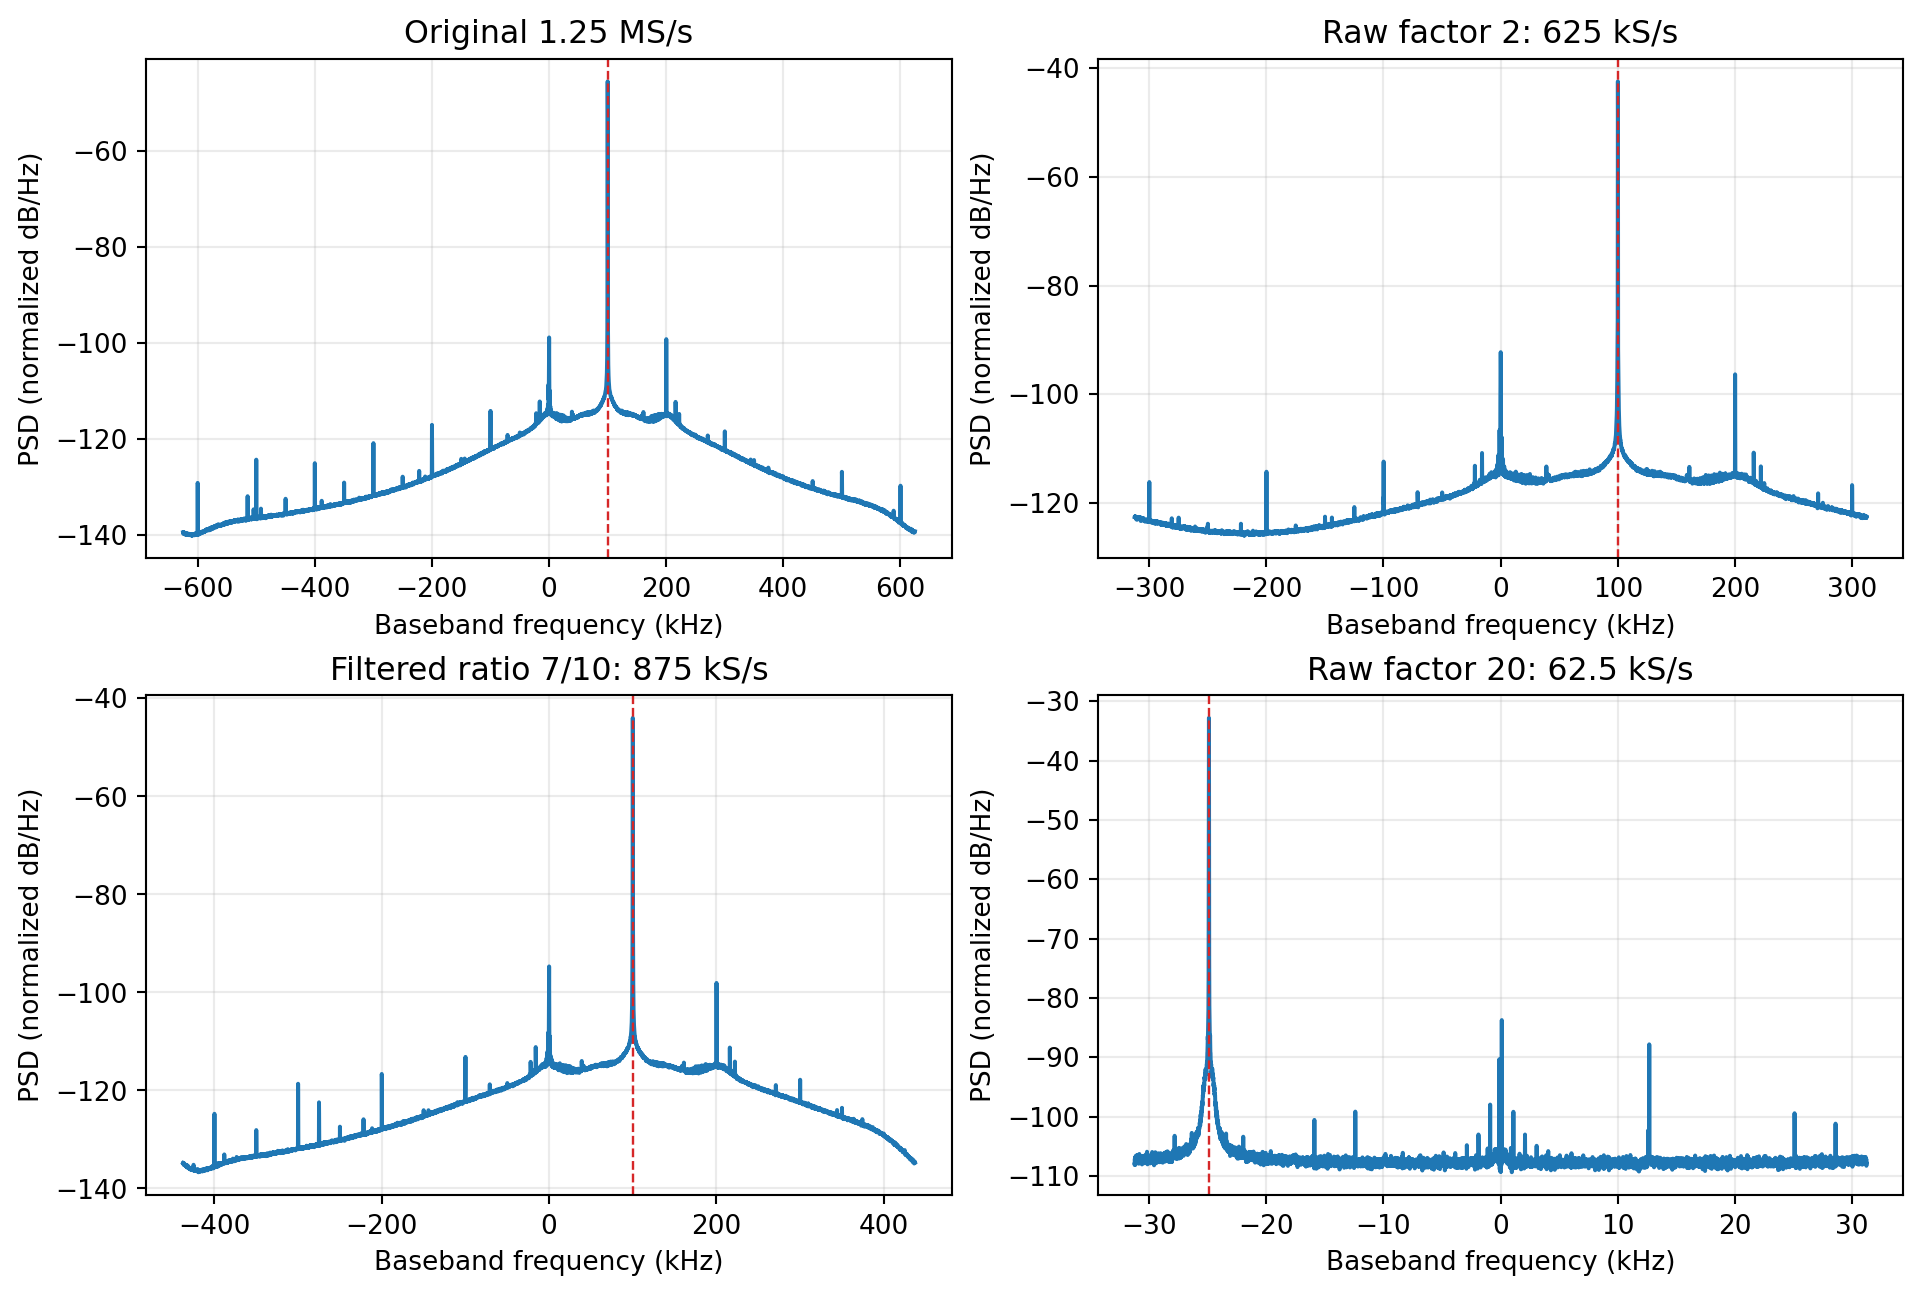

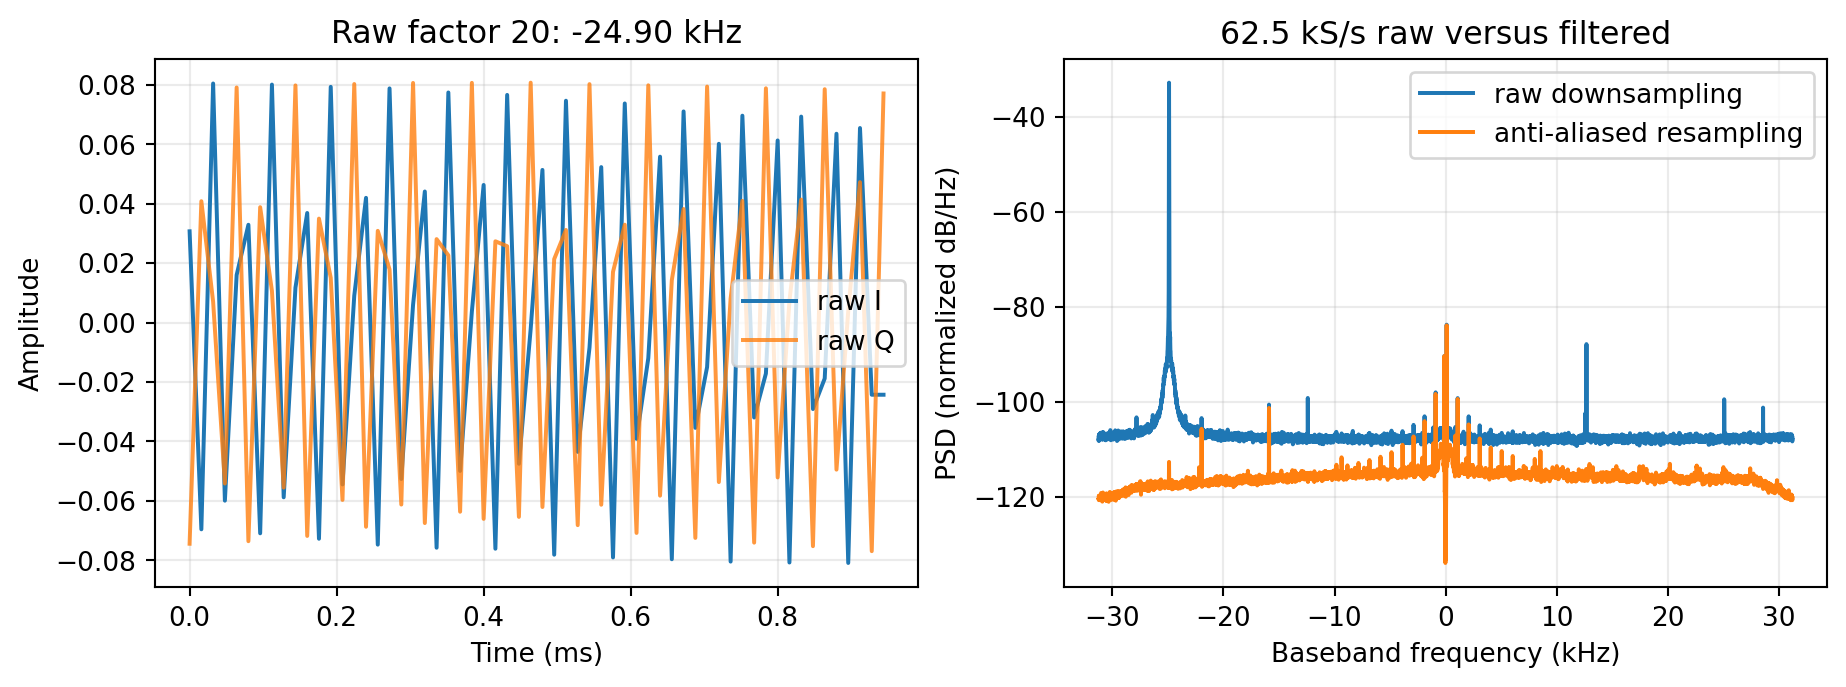

In [6]:
capture_path = CAPTURE_DIR / "task4_tone_c64.dat"
if not capture_path.is_file():
    raise FileNotFoundError("Capture task4_tone_c64.dat with GNU Radio before analysis.")
result = analyze_tone_capture(capture_path, sample_rate_sps, tone_hz)
for name, peak in result["peaks_hz"].items():
    print(f"{name:36s} peak {peak/1e3:9.3f} kHz, power {result['powers_db'][name]:8.3f} dB")
spectra_figure, alias_figure = plot_task4_analysis(result, FIGURE_DIR)
display(Image(filename=str(spectra_figure)))
display(Image(filename=str(alias_figure)))